In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_outlier_treated.csv')

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,on request,sector 103,1.69,9145.021645,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,8.0,NaN,Relatively New,1845.0,NaN,NaN,0,0,0,0,0,0,49,616.0
1,house,independent,sector 40,5.00,21123.785382,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,3.0,North-West,Moderately Old,NaN,263.0,NaN,0,1,1,0,0,1,83,263.0
2,flat,zara aavaas,sector 104,0.20,6644.518272,301.0,Built Up area: 301 (27.96 sq.m.),1,1,1,3.0,North-East,Undefined,NaN,301.0,NaN,0,0,0,0,0,0,67,301.0
3,house,independent,sector 23,2.80,17983.301220,1557.0,Plot area 173(16.07 sq.m.)Built Up area: 160 s...,5,5,3+,2.0,North-East,Old Property,NaN,160.0,150.0,0,0,0,1,0,1,74,311.4
4,house,independent,sector 47,5.15,26614.987080,1935.0,Plot area 215(179.77 sq.m.),3,9,3+,3.0,East,Relatively New,NaN,215.0,NaN,0,0,1,0,0,1,75,645.0


In [6]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1681
built_up_area          1970
carpet_area            1714
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

# built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

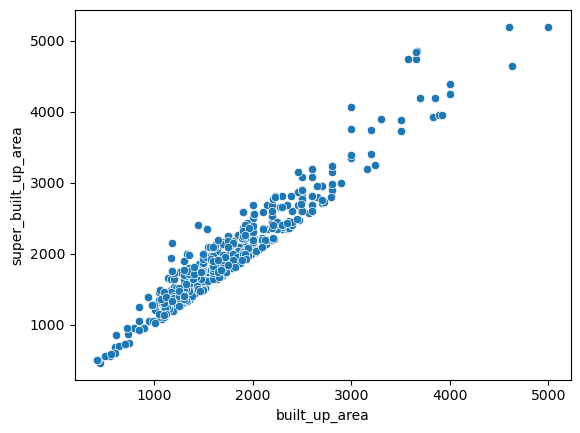

In [7]:
sns.scatterplot(x= df['built_up_area'], y= df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

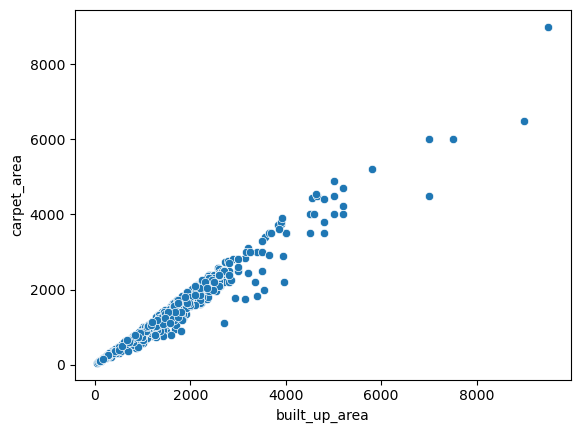

In [8]:
sns.scatterplot(x= df['built_up_area'], y= df['carpet_area'])

In [9]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3551    False
3552    False
3553    False
3554    False
3555    False
Length: 3556, dtype: bool

In [10]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [11]:
all_present_df.shape

(531, 24)

In [12]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/ all_present_df['built_up_area']).median()

In [13]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/ all_present_df['built_up_area']).median()

In [14]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [15]:
# both present built up null 
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [16]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
10,flat,tarc maceo,sector 91,0.87,6641.221374,1310.0,Super Built up area 1310(121.7 sq.m.)Carpet ar...,2,2,2,9.0,North-West,Relatively New,1310.0,NaN,1000.0,0,0,1,0,0,0,78,655.000000
18,flat,indiabulls centrum park,sector 103,1.65,8250.000000,2000.0,Super Built up area 2000(185.81 sq.m.)Carpet a...,3,3,3+,15.0,NaN,Relatively New,2000.0,NaN,1400.0,1,0,0,0,0,0,38,666.666667
21,flat,cghs airport apartment,sector 47,1.80,6000.000000,3000.0,Super Built up area 3000(278.71 sq.m.)Carpet a...,4,4,3+,4.0,North-West,Moderately Old,3000.0,NaN,2700.0,0,0,1,0,0,1,120,750.000000
24,flat,bestech park view ananda,sector 81,0.88,8043.875686,1094.0,Super Built up area 1360(126.35 sq.m.)Carpet a...,2,2,3,8.0,West,Relatively New,1360.0,NaN,1094.0,1,0,0,0,0,1,95,547.000000
39,flat,shree vardhman victoria,sector 70,1.65,8461.538462,1950.0,Super Built up area 1950(181.16 sq.m.)Carpet a...,3,4,3,5.0,South-East,Relatively New,1950.0,NaN,1161.0,0,1,0,0,1,1,49,650.000000


In [17]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2), inplace= True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_25992\3089369129.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2), inplace= True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_25992\3089369129.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [18]:
df.update(sbc_df)

In [19]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1681
built_up_area          1549
carpet_area            1714
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [20]:
# sb present c is null built up null 
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [21]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,on request,sector 103,1.69,9145.021645,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,8.0,NaN,Relatively New,1845.0,NaN,NaN,0,0,0,0,0,0,49,616.000000
6,flat,tulip violet,sector 69,1.29,8227.040816,1568.0,Super Built up area 1568(145.67 sq.m.),3,3,1,12.0,North-East,Relatively New,1568.0,NaN,NaN,0,0,0,1,0,1,86,522.666667
17,flat,godrej aria,sector 79,1.10,7773.851590,1415.0,Super Built up area 1351(125.51 sq.m.),2,2,3+,4.0,North-East,New Property,1351.0,NaN,NaN,0,0,0,0,0,1,49,707.500000
20,flat,tulip monsella,sector 53,8.25,28004.073320,2946.0,Super Built up area 2940(273.13 sq.m.),3,4,3,8.0,NaN,Undefined,2940.0,NaN,NaN,0,1,0,0,0,2,35,982.000000
22,flat,tulip violet,sector 69,1.30,8285.532186,1569.0,Super Built up area 1568(145.67 sq.m.),3,3,1,12.0,South-West,Relatively New,1568.0,NaN,NaN,0,0,0,1,0,0,86,523.000000


In [22]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105), inplace= True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_25992\2185824705.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105), inplace= True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_25992\2185824705.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(rou

In [23]:
df.update(sb_df)

In [24]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1681
built_up_area           674
carpet_area            1714
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [25]:
# sb null c is present built up null 
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [26]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
8,flat,signature global solera,sector 107,0.28,5833.333333,480.0,Carpet area: 489 (45.43 sq.m.),2,2,2,0.0,North-East,Relatively New,NaN,NaN,489.0,0,0,0,0,0,0,45,240.000000
14,flat,shapoorji pallonji joyville gurugram,sector 102,1.05,11475.409836,915.0,Carpet area: 915 (85.01 sq.m.),2,2,2,0.0,NaN,Undefined,NaN,NaN,915.0,0,0,0,0,0,0,49,457.500000
15,flat,supertech araville,sector 79,0.80,5266.622778,1519.0,Carpet area: 1519 (141.12 sq.m.),2,2,2,12.0,NaN,New Property,NaN,NaN,1519.0,1,0,0,0,0,0,49,759.500000
27,flat,siddhartha apartment,sector 95,1.10,4327.301338,2542.0,Carpet area: 2542 (236.16 sq.m.),4,3,3,9.0,North,Relatively New,NaN,NaN,2542.0,0,1,0,0,1,0,22,635.500000
35,flat,signature global city,sector 37d,1.10,8800.000000,1250.0,Carpet area: 1250 (116.13 sq.m.),3,3,3,1.0,NaN,Undefined,NaN,NaN,1250.0,0,0,0,0,0,0,16,416.666667


In [27]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9), inplace= True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_25992\785797264.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9), inplace= True)
C:\Users\ACER\AppData\Local\Temp\ipykernel_25992\785797264.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet

In [28]:
df.update(c_df)

In [29]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1011
agePossession             0
super_built_up_area    1681
built_up_area             0
carpet_area            1714
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

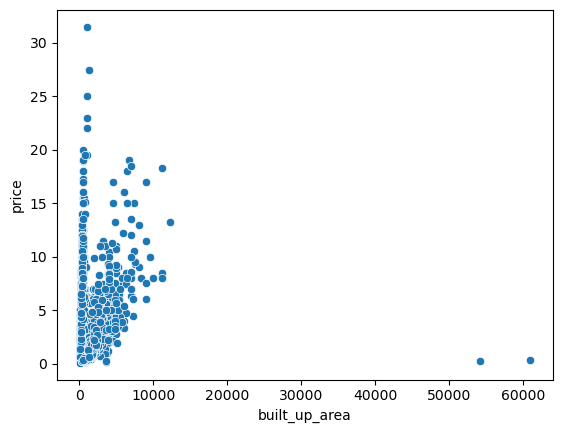

In [30]:
sns.scatterplot( x= df['built_up_area'], y= df['price'])

In [31]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price', 'area', 'built_up_area']]

In [32]:
anamoly_df.sample(5)

,price,area,built_up_area
2752,4.50,1350.0,150.0
1568,2.80,1500.0,1500.0
1027,8.20,3240.0,360.0
13,12.00,3150.0,350.0
1839,3.75,1467.0,163.0


In [33]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [34]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

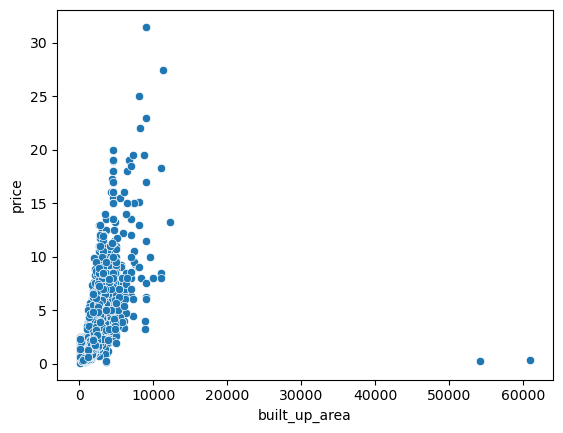

In [35]:
sns.scatterplot(x=df['built_up_area'], y=df['price'])

In [36]:
df.drop(columns=['area', 'areaWithType', 'super_built_up_area', 'carpet_area', 'area_room_ratio'], inplace= True)

In [37]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,on request,sector 103,1.69,9145.021645,3,3,3+,8.0,NaN,Relatively New,1670.0,0,0,0,0,0,0,49
1,house,independent,sector 40,5.00,21123.785382,9,9,3+,3.0,North-West,Moderately Old,2367.0,0,1,1,0,0,1,83
2,flat,zara aavaas,sector 104,0.20,6644.518272,1,1,1,3.0,North-East,Undefined,301.0,0,0,0,0,0,0,67
3,house,independent,sector 23,2.80,17983.301220,5,5,3+,2.0,North-East,Old Property,1557.0,0,0,0,1,0,1,74
4,house,independent,sector 47,5.15,26614.987080,3,9,3+,3.0,East,Relatively New,1935.0,0,0,1,0,0,1,75


In [38]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

# floorNum

In [39]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
124,house,independent,sector 26,4.60,12198.355874,4,4,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,0,28
140,house,independent,sector 7,6.50,15046.296296,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,0,9
148,house,emaar mgf marbella,sector 66,9.00,21251.475797,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,1,114
362,house,independent,sector 2,5.60,17283.950617,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0
505,house,jacob pura,sector 12,0.35,9722.222222,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,0,0
736,house,independent,sector 4,0.65,11111.111111,4,2,2,NaN,NaN,Moderately Old,65.0,0,0,0,0,0,0,0
1194,flat,NaN,sector 78,0.60,3692.307692,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,0,0
1196,house,independent,sector 25,13.00,45710.267229,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,2,0
1428,house,dlf new town heights,sector 86,2.47,7718.750000,4,4,3+,NaN,West,Moderately Old,2800.0,0,1,0,1,0,1,130
1436,house,ansal sushant lok plots,sector 43,3.30,26570.048309,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0


In [40]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [41]:
df['floorNum'].fillna(2.0, inplace= True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_25992\2768453495.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0, inplace= True)


In [42]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1011
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [43]:
1011 /df.shape[0]

0.28430821147356583

# facing

<Axes: ylabel='count'>

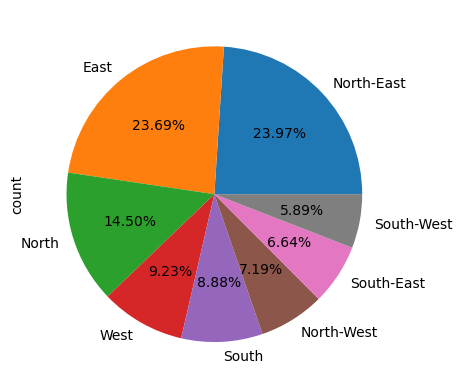

In [44]:
df['facing'].value_counts().plot(kind='pie', autopct = '%0.2f%%')

In [45]:
df.drop(columns=['facing'], inplace= True)

In [46]:
df.sample(2)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1079,flat,parsvnath exotica,sector 53,5.00,17241.379310,3,4,3,7.0,Old Property,3222.0,0,1,0,0,0,1,24
2067,flat,godrej nature plus,sector 33,1.15,11557.788945,2,2,2,15.0,Undefined,103.0,0,0,0,0,0,0,38


In [47]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [51]:
df.drop(index = [1194], inplace = True)

In [52]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

# agePossession

In [53]:
df['agePossession'].value_counts()

agePossession
Relatively New        1607
New Property           557
Moderately Old         544
Undefined              431
Old Property           293
Under Construction     123
Name: count, dtype: int64

In [59]:
df[df["agePossession"] == "Undefined"]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2,flat,zara aavaas,sector 104,0.20,6644.518272,1,1,1,3.0,Undefined,301.0,0,0,0,0,0,0,67
7,flat,shree vardhman victoria,sector 70,1.75,8974.358974,3,5,0,0.0,Undefined,1950.0,0,0,0,0,0,0,47
14,flat,shapoorji pallonji joyville gurugram,sector 102,1.05,11475.409836,2,2,2,0.0,Undefined,1017.0,0,0,0,0,0,0,49
19,flat,signature global city 63a,sector 63a,2.00,12804.097311,3,3,2,1.0,Undefined,1540.0,0,0,0,0,0,0,36
20,flat,tulip monsella,sector 53,8.25,28004.073320,3,4,3,8.0,Undefined,2661.0,0,1,0,0,0,2,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3521,flat,godrej nature plus,sector 33,1.75,8767.535070,3,3,0,2.0,Undefined,1996.0,0,0,0,0,0,0,56
3528,flat,godrej air,sector 85,1.35,13636.363636,2,2,3,19.0,Undefined,102.0,0,0,0,0,0,0,44
3533,flat,dlf the arbour,sector 63,7.90,20000.000000,4,4,3+,34.0,Undefined,3950.0,0,0,0,0,0,0,61
3538,flat,m3m golf hills,sector 79,1.45,10211.267606,2,2,3,15.0,Undefined,1578.0,0,0,0,0,0,0,67


In [61]:
def mode_based_imputation(row):
    if row["agePossession"] == "Undefined":
        mode_value = df[
            (df["sector"] == row["sector"])
            & (df["property_type"] == row["property_type"])
        ]["agePossession"].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row["agePossession"]

In [62]:
df['agePossession'] = df.apply(mode_based_imputation, axis= 1)

In [63]:
df['agePossession'].value_counts()

agePossession
Relatively New        1784
New Property           635
Moderately Old         585
Old Property           331
Under Construction     129
Undefined               91
Name: count, dtype: int64

In [64]:
def mode_based_imputation2(row):
    if row["agePossession"] == "Undefined":
        mode_value = df[(df["sector"] == row["sector"])]["agePossession"].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row["agePossession"]

In [65]:
df['agePossession'] = df.apply(mode_based_imputation2, axis= 1)

In [66]:
df['agePossession'].value_counts()

agePossession
Relatively New        1800
New Property           657
Moderately Old         592
Old Property           342
Under Construction     129
Undefined               35
Name: count, dtype: int64

In [71]:
def mode_based_imputation3(row):
    if row["agePossession"] == "Undefined":
        mode_value = df[(df["property_type"] == row["property_type"])][
            "agePossession"
        ].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row["agePossession"]

In [72]:
df["agePossession"] = df.apply(mode_based_imputation3, axis=1)

In [73]:
df["agePossession"].value_counts()

agePossession
Relatively New        1812
New Property           657
Moderately Old         615
Old Property           342
Under Construction     129
Name: count, dtype: int64

In [74]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [75]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv', index= False)

In [76]:
df.shape

(3555, 18)